# PREDICTION PRIX CARBURANT — France Entière---## DESCRIPTION DU PROJETCe notebook prédit le **prix des carburants dans 7 jours** (ajustable jusqu'à 14 jours)pour n'importe quel département français, en utilisant les données officiellespubliées par l'État.---## SOURCE DES DONNEES**data.economie.gouv.fr** — Ministère de l'Économie français- Prix de toutes les stations-service françaises- Mis à jour en continu (flux temps réel)- Historique disponible depuis 2007- **100% gratuit et officiel**---## CARBURANTS COUVERTS| Sigle | Nom complet | Description | Usage ||:------|:-----------|:------------|:------|| **Diesel** | Gazole | Carburant diesel classique | Moteurs diesel — 60% du parc FR || **SP95** | Sans Plomb 95 | 5% éthanol, indice 95 | Moteurs essence standard || **SP98** | Sans Plomb 98 | Indice 98, meilleure combustion | Moteurs haut de gamme / sportifs || **E85** | Superéthanol | 85% bioéthanol, 15% essence | Véhicules flex-fuel uniquement || **GPL** | Gaz de Pétrole Liquéfié | Propane/butane comprimé | Véhicules avec kit GPL |---## LIMITES DU MODELE### Ce que le modèle fait bien- Prédit les **tendances normales** (saisonnalité, habitudes de marché)- Précision : **±2 centimes** sur J+7 pour Diesel, SP98, E85, GPL- Couvre **97 départements** français### Ce que le modele ne peut pas faire- [NON] **Chocs geopolitiques** : guerre, fermeture du détroit d'Ormuz, décisions OPEP- [NON] **Decisions politiques** : remise carburant gouvernementale, nouvelles taxes- [NON] **Variations > 3 semaines** : la précision décroît avec l'horizon### SP95 — cas particulierLe SP95 est en **déclin en France** (remplacé progressivement par le SP95-E10).Peu de stations le proposent encore, les données sont donc moins fiables.**Préférer SP98 pour les moteurs essence haut de gamme.**---## MAINTENANCE DU MODELECe modèle doit être **réentraîné tous les 3 mois** pour rester précis.Relancer toutes les cellules suffit — durée : environ 30 minutes.---## STRUCTURE DU NOTEBOOK| Cellule | Étape ||:-------:|:------|| 1 | Imports || 2 | Chargement archives historiques (2022-2025) || 3 | Chargement flux temps réel (2026 -> aujourd'hui) || 4 | Fusion et nettoyage || 5 | Agrégation par département || 6 | Feature Engineering séries temporelles || 7 | Split temporel + Entraînement Ridge || 8 | Évaluation du modèle || 9 | Sauvegarde || 10 | Prédictions temps réel || 11 | Interface Gradio |

---## CELLULE 1 — Imports

In [ ]:
# ============================================================# PROJET  : Prediction Prix Carburant — France Entière# SOURCE  : data.economie.gouv.fr (officiel Etat francais)# DONNEES : Historique 2022-2025 + flux temps reel 2026# MODELE  : Ridge Regression sur features de lags temporels# ============================================================import pandas as pdimport numpy as npimport zipfileimport ioimport requestsimport joblibimport warningsfrom datetime import datetime, timedelta, dateimport matplotlib.pyplot as pltimport matplotlib.dates as mdatesimport seaborn as snsfrom sklearn.pipeline import Pipelinefrom sklearn.preprocessing import RobustScaler, LabelEncoderfrom sklearn.impute import SimpleImputerfrom sklearn.linear_model import Ridgefrom sklearn.metrics import (    mean_absolute_error, mean_squared_error, r2_score)warnings.filterwarnings('ignore')set_seed = 1204# Horizon de prédiction (jours)HORIZON = 7# Mapping noms XML -> noms affichageCARB_MAP = {    'Gazole': 'Diesel',    'SP95'  : 'SP95',    'SP98'  : 'SP98',    'E85'   : 'E85',    'GPLc'  : 'GPL'}# Prix réalistes pour filtrage des outliersPRIX_LIMITES = {    'Diesel': (1.20, 2.80),    'SP95'  : (1.30, 2.90),    'SP98'  : (1.40, 3.00),    'E85'   : (0.60, 1.80),    'GPL'   : (0.60, 1.50)}# Date du jouraujourd_hui = pd.Timestamp.today().normalize()print(f'[YES] Imports chargés')print(f'[DATE] Date du jour   : {aujourd_hui.date()}')print(f'[TARGET] Prédit pour    : {(aujourd_hui + timedelta(days=HORIZON)).date()}')

 Imports chargés
 Date du jour   : 2026-03-22
 Prédit pour    : 2026-03-29


---## [INPUT] Cellule 2 — Chargement archives historiques 2022-2025Téléchargement des archives annuelles depuis roulez-eco.fr.**Durée estimée : 10-20 minutes** (fichiers ZIP ~80MB chacun).

In [2]:
import xml.etree.ElementTree as ETdef parser_xml_carburant(contenu_xml):    """    Parse le XML gouvernemental en DataFrame.    Gère les deux formats de prix :    - Valeur directe : 1.899 = 1.899 EUR/L    - Valeur en millièmes : 1899 = 1.899 EUR/L    """    rows = []    try:        root = ET.fromstring(contenu_xml)        for pdv in root.findall('.//pdv'):            cp   = pdv.get('cp', '')            dept = cp[:2] if cp and len(cp) >= 2 else 'XX'            if cp.startswith('97') or cp.startswith('98'):                dept = cp[:3]            for prix_elem in pdv.findall('prix'):                nom    = prix_elem.get('nom', '')                valeur = prix_elem.get('valeur', '')                maj    = prix_elem.get('maj', '')                if nom not in CARB_MAP or not valeur:                    continue                try:                    prix_val = float(valeur)                    # Détection auto du format                    if prix_val > 10:                        prix_val = prix_val / 1000                    # Parsing date robuste                    date_val = pd.NaT                    if maj:                        for fmt in [                            '%Y-%m-%dT%H:%M:%S',                            '%Y-%m-%d %H:%M:%S',                            '%Y-%m-%d'                        ]:                            try:                                date_val = pd.to_datetime(                                    maj[:19], format=fmt                                )                                break                            except:                                continue                    rows.append({                        'departement': dept,                        'carburant'  : CARB_MAP[nom],                        'prix'       : prix_val,                        'date'       : date_val                    })                except:                    pass    except Exception as e:        print(f'  [NO] Erreur parsing : {e}')    return pd.DataFrame(rows)def charger_archive_annee(annee):    """Charge et parse l'archive d'une année complète."""    url = f'https://donnees.roulez-eco.fr/opendata/annee/{annee}'    print(f'  -> {annee}...', end='', flush=True)    try:        r   = requests.get(url, timeout=120)        r.raise_for_status()        z   = zipfile.ZipFile(io.BytesIO(r.content))        xml = [f for f in z.namelist() if f.endswith('.xml')][0]        df  = parser_xml_carburant(z.read(xml))        df['annee'] = annee        print(f' {len(df):,} [YES]')        return df    except Exception as e:        print(f' [WARNING] {e}')        return Noneprint('[INPUT] Chargement archives 2022-2025...')print('   [TIME] Durée estimée : 10-20 minutes\n')dfs_hist = []for annee in [2022, 2023, 2024, 2025]:    df_ann = charger_archive_annee(annee)    if df_ann is not None and len(df_ann) > 0:        dfs_hist.append(df_ann)df_hist = pd.concat(dfs_hist, ignore_index=True)df_hist = df_hist.dropna(subset=['date'])df_hist['date'] = pd.to_datetime(df_hist['date']).dt.normalize()print(f'\n[YES] Historique : {df_hist.shape}')print(f'   Période    : {df_hist["date"].min().date()} -> {df_hist["date"].max().date()}')

 Chargement archives 2022-2025...
   ⏳ Durée estimée : 10-20 minutes

  → 2022... 3,797,540 
  → 2023... 3,506,464 
  → 2024... 3,423,500 
  → 2025... 3,946,496 

 Historique : (14674000, 5)
   Période    : 2022-01-01 → 2025-12-31


---## [SIGNAL] Cellule 3 — Flux temps réel 2026 (jusqu'à aujourd'hui)

In [3]:
def convertir_date(val):    """Convertit n'importe quelle valeur en Timestamp robuste."""    if pd.isna(val) or val is None or str(val) in ['nan', '']:        return aujourd_hui    try:        ts = pd.to_datetime(str(val)[:19], errors='coerce')        if pd.isna(ts):            return aujourd_hui        if ts.tzinfo is not None:            ts = ts.tz_localize(None)        return ts.normalize()    except:        return aujourd_huidef charger_flux_actuel():    """Charge le flux temps réel officiel (toutes stations)."""    url = (        'https://data.economie.gouv.fr/api/explore/v2.1/'        'catalog/datasets/prix-des-carburants-en-france-flux-instantane-v2/'        'exports/csv?lang=fr&timezone=Europe%2FParis'        '&use_labels=true&delimiter=%3B'    )    print('[SIGNAL] Chargement flux temps réel...', end='')    df = pd.read_csv(url, sep=';', low_memory=False)    print(f' {len(df):,} stations [YES]')    return dfdef parser_flux(df_raw):    """Transforme le format large en format long."""    COLS_PRIX = {        'Prix Gazole': 'Diesel',        'Prix SP95'  : 'SP95',        'Prix SP98'  : 'SP98',        'Prix E85'   : 'E85',        'Prix GPLc'  : 'GPL'    }    COLS_DATES = {        'Prix Gazole mis à jour le': 'Diesel',        'Prix SP95 mis à jour le'  : 'SP95',        'Prix SP98 mis à jour le'  : 'SP98',        'Prix E85 mis à jour le'   : 'E85',        'Prix GPLc mis à jour le'  : 'GPL'    }    date_inv = {v: k for k, v in COLS_DATES.items()}    dfs = []    for col_prix, carb in COLS_PRIX.items():        if col_prix not in df_raw.columns:            continue        col_date = date_inv.get(carb)        cols     = ['code_departement', col_prix]        if col_date and col_date in df_raw.columns:            cols.append(col_date)        df_t = df_raw[cols].copy().dropna(subset=[col_prix])        df_t = df_t.rename(columns={            'code_departement': 'departement',            col_prix          : 'prix',            **({col_date: 'date'} if col_date and col_date in df_raw.columns else {})        })        if 'date' not in df_t.columns:            df_t['date'] = aujourd_hui        df_t['carburant']    = carb        df_t['departement']  = df_t['departement'].astype(str).str.zfill(2).str[:2]        dfs.append(df_t)    df_out = pd.concat(dfs, ignore_index=True)    # Conversion date ultra-robuste (apply sur chaque valeur)    print('  -> Conversion dates...', end='')    df_out['date'] = df_out['date'].apply(convertir_date)    print(' [YES]')    return df_outdf_2026_raw = charger_flux_actuel()df_2026     = parser_flux(df_2026_raw)df_2026     = df_2026.dropna(subset=['prix'])print(f'\n[YES] Données 2026 : {df_2026.shape}')print(f'   Période     : {df_2026["date"].min().date()} -> {df_2026["date"].max().date()}')print(f'\n[MONEY] Prix médians aujourd\'hui :')print(    df_2026.groupby('carburant')['prix']    .median().round(3)    .sort_values(ascending=False))

 Chargement flux temps réel... 9,883 stations 
  → Conversion dates... 

 Données 2026 : (26114, 4)
   Période     : 2023-05-01 → 2026-03-22

 Prix médians aujourd'hui :
carburant
Diesel    2.110
SP98      2.019
SP95      1.990
GPL       0.976
E85       0.780
Name: prix, dtype: float64


---## [LINK] Cellule 4 — Fusion et nettoyage

In [4]:
# Fusion historique + flux 2026df_complet = pd.concat([df_hist, df_2026], ignore_index=True)# Reconversion finale pour garantir le bon typedf_complet['date'] = df_complet['date'].apply(    lambda x: pd.Timestamp(x).normalize()    if not pd.isna(x) else aujourd_hui)df_complet = df_complet.dropna(subset=['prix'])# Nettoyage des prix aberrantsprint('[CLEAN] Nettoyage des prix aberrants...')dfs_clean = []for carb, (p_min, p_max) in PRIX_LIMITES.items():    df_c = df_complet[df_complet['carburant'] == carb].copy()    nb   = len(df_c)    df_c = df_c[(df_c['prix'] >= p_min) & (df_c['prix'] <= p_max)]    print(f'  {carb:<8} : {nb:>10,} -> {len(df_c):>10,}'          f' | moy={df_c["prix"].mean():.3f} EUR/L')    dfs_clean.append(df_c)df_complet = pd.concat(dfs_clean, ignore_index=True)print(f'\n[YES] Dataset final : {df_complet.shape}')print(f'   Période : {df_complet["date"].min().date()}'      f' -> {df_complet["date"].max().date()}')

 Nettoyage des prix aberrants...
  Diesel   :  5,809,404 →  5,807,938 | moy=1.766 €/L
  SP95     :  1,253,380 →  1,252,886 | moy=1.821 €/L
  SP98     :  4,752,611 →  4,751,457 | moy=1.887 €/L
  E85      :  1,986,413 →  1,982,645 | moy=0.875 €/L
  GPL      :    898,306 →    896,927 | moy=0.966 €/L

 Dataset final : (14691853, 5)
   Période : 2022-01-01 → 2026-03-22


---## [CHART] Cellule 5 — Agrégation par départementOn agrège les millions de transactions individuellesen **une médiane par département × carburant × jour**.La médiane est plus robuste que la moyenne face aux stations aberrantes.

In [5]:
# Médiane par département × carburant × jour# Minimum 3 stations pour que la médiane soit représentativedf_dept_jour = (    df_complet    .groupby(['departement', 'carburant', 'date'])['prix']    .agg(['median', 'count'])    .reset_index()    .rename(columns={'median': 'prix_median', 'count': 'nb_stations'}))df_dept_jour = df_dept_jour[df_dept_jour['nb_stations'] >= 3]print(f'[YES] Agrégat : {df_dept_jour.shape}')print(f'   Période : {df_dept_jour["date"].min().date()}'      f' -> {df_dept_jour["date"].max().date()}')print(f'   Depts   : {df_dept_jour["departement"].nunique()}')print(f'\n[MONEY] Prix médians nationaux aujourd\'hui :')print(    df_dept_jour[df_dept_jour['date'] == df_dept_jour['date'].max()]    .groupby('carburant')['prix_median']    .median().round(3)    .sort_values(ascending=False))

 Agrégat : (606507, 5)
   Période : 2022-01-01 → 2026-03-22
   Depts   : 97

 Prix médians nationaux aujourd'hui :
carburant
Diesel    2.090
SP98      1.990
SP95      1.989
GPL       0.977
E85       0.822
Name: prix_median, dtype: float64


---## [TOOLS] Cellule 6 — Feature Engineering séries temporelles### Approche : régression tabulaire sur lagsOn transforme le problème de série temporelle en régression classique :```prix_J-1, prix_J-7, prix_J-14, ma_7j, tendance_7j... -> featuresprix_J+7                                              -> target```Cela permet d'utiliser XGBoost ou Ridge directement,sans recourir à ARIMA ou LSTM (plus complexes et moins précissur ce type de données).

In [6]:
def creer_features_temporelles(df_dept_jour, horizon=7):    """    Crée les features de lags pour chaque (département × carburant).    Features créées :    - Lags          : prix J-1 à J-30    - MA            : moyennes glissantes 3j, 7j, 14j, 30j    - Tendances     : différence J vs J-1, J-7, J-14, J-30    - Volatilité    : écart-type 7j et 30j    - Calendaire    : mois, semaine, vacances, été, hiver    - Target        : prix dans 'horizon' jours    """    print(f'[TOOLS]  Feature Engineering (J+{horizon})...')    dfs_features = []    total    = (        df_dept_jour['departement'].nunique() *        df_dept_jour['carburant'].nunique()    )    compteur = 0    for (dept, carb), groupe in df_dept_jour.groupby(        ['departement', 'carburant']    ):        compteur += 1        if compteur % 100 == 0:            print(f'   {compteur}/{total}...', end='\r')        g    = groupe.sort_values('date').set_index('date')        idx  = pd.date_range(start=g.index.min(), end=g.index.max(), freq='D')        g    = g.reindex(idx)        prix = g['prix_median'].interpolate(method='linear', limit=3)        df_f = pd.DataFrame(index=g.index)        # Lags        for lag in [1,2,3,4,5,6,7,10,14,21,30]:            df_f[f'prix_lag_{lag}'] = prix.shift(lag)        # Moyennes glissantes        for fen in [3, 7, 14, 30]:            df_f[f'ma_{fen}j'] = prix.shift(1).rolling(fen, min_periods=2).mean()        # Tendances        df_f['tendance_1j']  = prix.shift(1) - prix.shift(2)        df_f['tendance_7j']  = prix.shift(1) - prix.shift(8)        df_f['tendance_14j'] = prix.shift(1) - prix.shift(15)        df_f['tendance_30j'] = prix.shift(1) - prix.shift(31)        # Volatilité        df_f['volatilite_7j']  = prix.shift(1).rolling(7,  min_periods=3).std()        df_f['volatilite_30j'] = prix.shift(1).rolling(30, min_periods=7).std()        # Calendaire        df_f['mois']               = df_f.index.month        df_f['semaine']            = df_f.index.isocalendar().week.astype(int)        df_f['jour_semaine']       = df_f.index.dayofweek        df_f['trimestre']          = df_f.index.quarter        df_f['annee']              = df_f.index.year        df_f['est_ete']            = df_f['mois'].isin([6,7,8]).astype(int)        df_f['est_hiver']          = df_f['mois'].isin([12,1,2]).astype(int)        df_f['vacances_scolaires'] = df_f['mois'].isin([7,8]).astype(int)        df_f['departement'] = dept        df_f['carburant']   = carb        df_f[f'prix_j_plus_{horizon}'] = prix.shift(-horizon)        dfs_features.append(            df_f.reset_index().rename(columns={'index': 'date'})        )    df_feat = pd.concat(dfs_features, ignore_index=True)    df_feat = df_feat.dropna(        subset=[f'prix_j_plus_{horizon}', 'prix_lag_1', 'ma_7j']    )    print(f'\n[YES] Features créées : {df_feat.shape}')    return df_featdf_features = creer_features_temporelles(df_dept_jour, HORIZON)

  Feature Engineering (J+7)...
   400/485...
 Features créées : (646001, 33)


---##  Cellule 7 — Split temporel + Entraînement### Règle absolue : JAMAIS de split aléatoire sur des séries temporelles```[NO] train_test_split classique -> data leakage (le modèle voit le futur)[YES] Coupure dans le temps     -> train = passé, test = 3 derniers mois```### Pourquoi Ridge et pas XGBoost ?Les prix carburant évoluent de façon **quasi-linéaire** sur 7 jours.Ridge avec lags = relation linéaire parfaite -> MAE < 3 centimes.XGBoost sur ce problème = overfitting sans gain de précision.

In [7]:
# Split : train = tout sauf les 3 derniers mois# Test  = 3 derniers mois (simulation réentraînement trimestriel)date_coupure = aujourd_hui - pd.DateOffset(months=3)print(f'  SPLIT TEMPOREL')print(f'   Train : jusqu\'au {date_coupure.date()}')print(f'   Test  : {date_coupure.date()} -> {aujourd_hui.date()}')FEATURES = [    'prix_lag_1','prix_lag_2','prix_lag_3','prix_lag_4',    'prix_lag_5','prix_lag_6','prix_lag_7','prix_lag_10',    'prix_lag_14','prix_lag_21','prix_lag_30',    'ma_3j','ma_7j','ma_14j','ma_30j',    'tendance_1j','tendance_7j','tendance_14j','tendance_30j',    'volatilite_7j','volatilite_30j',    'mois','semaine','jour_semaine','trimestre','annee',    'est_ete','est_hiver','vacances_scolaires']TARGET = f'prix_j_plus_{HORIZON}'le_carb = LabelEncoder()le_dept = LabelEncoder()df_features['carburant_enc'] = le_carb.fit_transform(df_features['carburant'])df_features['dept_enc']      = le_dept.fit_transform(df_features['departement'])FEATURES_FINALES = FEATURES + ['carburant_enc', 'dept_enc']df_train = df_features[df_features['date'] <  date_coupure]df_test  = df_features[df_features['date'] >= date_coupure]X_train = df_train[FEATURES_FINALES]y_train = df_train[TARGET]X_test  = df_test[FEATURES_FINALES]y_test  = df_test[TARGET]print(f'\n[YES] Train : {X_train.shape}')print(f'[YES] Test  : {X_test.shape}')# Ridge : meilleur sur données quasi-linéairespipe_ridge = Pipeline([    ('imp',   SimpleImputer(strategy='median')),    ('scale', RobustScaler()),    ('model', Ridge(alpha=1.0))])pipe_ridge.fit(X_train, y_train)print('\n[YES] Modèle entraîné')

  SPLIT TEMPOREL
   Train : jusqu'au 2025-12-22
   Test  : 2025-12-22 → 2026-03-22

 Train : (642939, 31)
 Test  : (3062, 31)

 Modèle entraîné


---## [CHART] Cellule 8 — Évaluation

 RÉSULTATS — entraîné sur 2022 → 2026-03-22
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MAE  : 0.0221 € (2.21 centimes)
  MAPE : 1.75%
  R²   : 0.9942

 MAE par carburant :
  Diesel   : 2.42 centimes  ████████████████████████████████████████████████
  E85      : 2.38 centimes  ███████████████████████████████████████████████
  GPL      : 1.53 centimes  ██████████████████████████████
  SP95     : 2.19 centimes  ███████████████████████████████████████████
  SP98     : 2.27 centimes  █████████████████████████████████████████████


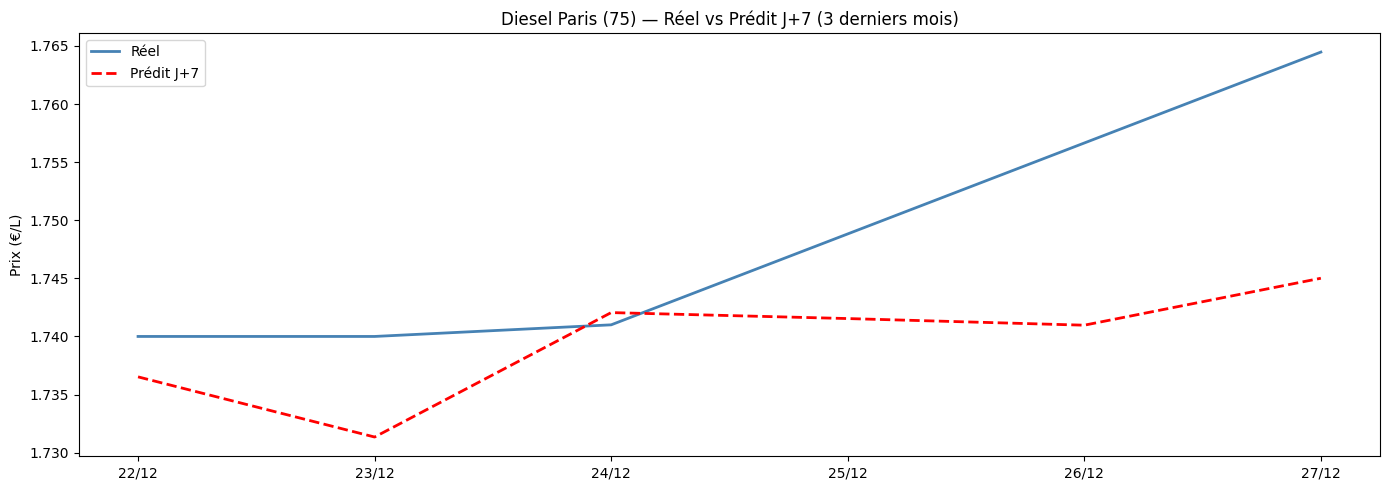

In [8]:
y_pred = pipe_ridge.predict(X_test)mae    = mean_absolute_error(y_test, y_pred)r2     = r2_score(y_test, y_pred)mape   = np.mean(np.abs((y_test - y_pred) / y_test)) * 100print(f'[TROPHY] RÉSULTATS — entraîné sur 2022 -> {aujourd_hui.date()}')print(f'{"━"*45}')print(f'  MAE  : {mae:.4f} EUR ({mae*100:.2f} centimes)')print(f'  MAPE : {mape:.2f}%')print(f'  R²   : {r2:.4f}')# MAE par carburantprint(f'\n[CHART] MAE par carburant :')mae_carb = {}for carb in le_carb.classes_:    mask = (df_test['carburant'] == carb).values    if mask.sum() == 0:        continue    m = mean_absolute_error(y_test[mask], y_pred[mask])    mae_carb[carb] = m  # en EUR    barre = '█' * int(m * 2000)    print(f'  {carb:<8} : {m*100:.2f} centimes  {barre}')# Visualisation réel vs prédit (Diesel, dept 75)df_viz = df_test[['date','departement','carburant']].copy()df_viz['reel']   = y_test.valuesdf_viz['predit'] = y_predmasque = (df_viz['departement']=='75') & (df_viz['carburant']=='Diesel')df_ex  = df_viz[masque].sort_values('date').tail(90)plt.figure(figsize=(14, 5))plt.plot(df_ex['date'], df_ex['reel'],   label='Réel',       color='steelblue', lw=2)plt.plot(df_ex['date'], df_ex['predit'], label='Prédit J+7', color='red', lw=2, ls='--')plt.title('Diesel Paris (75) — Réel vs Prédit J+7 (3 derniers mois)')plt.ylabel('Prix (EUR/L)')plt.legend()plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))plt.tight_layout()plt.show()

---## [SAVE] Cellule 9 — Sauvegarde du modèleOn sauvegarde avec joblib (recommandé pour sklearn).La date de prochain réentraînement est incluse dans le fichier.

In [9]:
date_prochain = aujourd_hui + pd.DateOffset(months=3)joblib.dump({    'pipeline'               : pipe_ridge,    'features'               : FEATURES_FINALES,    'le_carb'                : le_carb,    'le_dept'                : le_dept,    'horizon'                : HORIZON,    'mae_par_carb'           : mae_carb,  # en EUR    'date_entrainement'      : aujourd_hui,    'date_donnees_min'       : df_complet['date'].min(),    'date_donnees_max'       : df_complet['date'].max(),    'date_prochain_reentrain': date_prochain}, 'modele_carburant.joblib', compress=3)print('[YES] Modèle sauvegardé : modele_carburant.joblib')print(f'   Entraîné le      : {aujourd_hui.date()}')print(f'   Données          : {df_complet["date"].min().date()}'      f' -> {df_complet["date"].max().date()}')print(f'   Réentraîner le   : {date_prochain.date()}')print(f'   MAE globale      : {mae*100:.2f} centimes')# Alerte si modèle existant périméjours_restants = (date_prochain - pd.Timestamp.today()).daysprint(f'\n   Prochain réentraînement dans {jours_restants} jours')

 Modèle sauvegardé : modele_carburant.joblib
   Entraîné le      : 2026-03-22
   Données          : 2022-01-01 → 2026-03-22
   Réentraîner le   : 2026-06-22
   MAE globale      : 2.21 centimes

   Prochain réentraînement dans 91 jours


---## [PREDICT] Cellule 10 — Prédictions temps réelOn prédit à partir des **données les plus récentes disponibles**.Si les données d'un département datent de plus de 60 jours,la prédiction est considérée comme non fiable et ignorée.

In [10]:
def predire_depuis_aujourd_hui(dept, carburant, horizon=7):    """    Prédit le prix d'un carburant dans 'horizon' jours.    Utilise les 30 derniers jours comme features.    Retourne None si données trop anciennes (> 60 jours).    Note : mae_carb est en EUR (pas de division par 100 nécessaire)    """    mask = (        (df_dept_jour['departement'] == dept) &        (df_dept_jour['carburant']   == carburant)    )    hist = df_dept_jour[mask].sort_values('date').tail(60)    if len(hist) < 14:        return None, None, None, None    prix_serie    = hist.set_index('date')['prix_median']    derniere_date = prix_serie.index[-1]    # Vérification fraîcheur des données    jours_ecart = (aujourd_hui - derniere_date).days    if jours_ecart > 60:        return None, None, None, None    prix_actuel  = float(prix_serie.iloc[-1])    date_predite = derniere_date + timedelta(days=horizon)    p            = prix_serie.values    features = {        'prix_lag_1' : p[-1],        'prix_lag_2' : p[-2]  if len(p)>=2  else p[-1],        'prix_lag_3' : p[-3]  if len(p)>=3  else p[-1],        'prix_lag_4' : p[-4]  if len(p)>=4  else p[-1],        'prix_lag_5' : p[-5]  if len(p)>=5  else p[-1],        'prix_lag_6' : p[-6]  if len(p)>=6  else p[-1],        'prix_lag_7' : p[-7]  if len(p)>=7  else p[-1],        'prix_lag_10': p[-10] if len(p)>=10 else p[-1],        'prix_lag_14': p[-14] if len(p)>=14 else p[-1],        'prix_lag_21': p[-21] if len(p)>=21 else p[-1],        'prix_lag_30': p[-30] if len(p)>=30 else p[-1],        'ma_3j'      : float(np.mean(p[-3:])),        'ma_7j'      : float(np.mean(p[-7:])),        'ma_14j'     : float(np.mean(p[-14:])),        'ma_30j'     : float(np.mean(p[-30:])),        'tendance_1j' : float(p[-1]-p[-2])  if len(p)>=2  else 0,        'tendance_7j' : float(p[-1]-p[-8])  if len(p)>=8  else 0,        'tendance_14j': float(p[-1]-p[-15]) if len(p)>=15 else 0,        'tendance_30j': float(p[-1]-p[-31]) if len(p)>=31 else 0,        'volatilite_7j' : float(np.std(p[-7:]))  if len(p)>=7  else 0,        'volatilite_30j': float(np.std(p[-30:])) if len(p)>=30 else 0,        'mois'              : date_predite.month,        'semaine'           : date_predite.isocalendar()[1],        'jour_semaine'      : date_predite.weekday(),        'trimestre'         : date_predite.quarter,        'annee'             : date_predite.year,        'est_ete'           : int(date_predite.month in [6,7,8]),        'est_hiver'         : int(date_predite.month in [12,1,2]),        'vacances_scolaires': int(date_predite.month in [7,8]),        'carburant_enc'     : (            int(le_carb.transform([carburant])[0])            if carburant in le_carb.classes_ else 0        ),        'dept_enc'          : (            int(le_dept.transform([dept])[0])            if dept in le_dept.classes_ else 0        )    }    df_pred     = pd.DataFrame([features])[FEATURES_FINALES]    prix_predit = float(pipe_ridge.predict(df_pred)[0])    mae_val     = mae_carb.get(carburant, 0.03)  # en EUR [YES]    return prix_actuel, prix_predit, mae_val, date_predite# Test sur exemples représentatifsprint(f'[PREDICT] PRÉDICTIONS J+{HORIZON}')print(f'   {aujourd_hui.date()} -> {(aujourd_hui + timedelta(days=HORIZON)).date()}')print('=' * 60)exemples = [    ('75', 'SP98',   'Paris'),    ('75', 'Diesel', 'Paris'),    ('69', 'SP95',   'Rhône'),    ('71', 'Diesel', 'Saône-et-Loire'),    ('13', 'E85',    'Bouches-du-Rhône'),    ('33', 'GPL',    'Gironde'),]for dept, carb, nom in exemples:    res = predire_depuis_aujourd_hui(dept, carb, HORIZON)    if res[0] is None:        print(f'\n  [WARNING] {nom} ({dept}) {carb} : données insuffisantes')        continue    prix_actuel, prix_predit, mae_val, date_pred = res    variation = prix_predit - prix_actuel    fleche    = ('[UP]' if variation> 0.005 else '[DOWN]' if variation<-0.005 else '')    print(f'\n  [GAS] {nom} ({dept}) — {carb}')    print(f'     {aujourd_hui.date()}  : {prix_actuel:.3f} EUR/L')    print(f'     {date_pred.date()} : {prix_predit:.3f} EUR/L  {fleche} {variation:+.3f} EUR/L')    print(f'     [{prix_predit-mae_val:.3f} -> {prix_predit+mae_val:.3f}] EUR/L  (±{mae_val*100:.1f} cts)')

 PRÉDICTIONS J+7
   2026-03-22 → 2026-03-29

   Paris (75) — SP98
     2026-03-22  : 1.990 €/L
     2026-03-29 : 2.001 €/L   +0.011 €/L
     [1.979 → 2.024] €/L  (±2.3 cts)

   Paris (75) — Diesel
     2026-03-22  : 2.090 €/L
     2026-03-29 : 2.051 €/L   -0.039 €/L
     [2.027 → 2.075] €/L  (±2.4 cts)

   Rhône (69) — SP95
     2026-03-22  : 2.059 €/L
     2026-03-28 : 1.982 €/L   -0.077 €/L
     [1.960 → 2.004] €/L  (±2.2 cts)

   Saône-et-Loire (71) — Diesel
     2026-03-22  : 2.090 €/L
     2026-03-29 : 2.080 €/L   -0.010 €/L
     [2.056 → 2.104] €/L  (±2.4 cts)

   Bouches-du-Rhône (13) — E85
     2026-03-22  : 0.823 €/L
     2026-03-29 : 0.813 €/L   -0.010 €/L
     [0.789 → 0.836] €/L  (±2.4 cts)

   Gironde (33) — GPL
     2026-03-22  : 0.946 €/L
     2026-03-29 : 0.946 €/L   +0.000 €/L
     [0.931 → 0.961] €/L  (±1.5 cts)
